# Exploring multi-colour text and missing transcriptions

This notebook is a parameterised, exploratory sibling of `pagexml-image-region-linking.ipynb`:
instead of a single hard-coded scan, pick any `<institute_id>/<archive_id>/<inventory_num_id>`
(defaulting to `NL-AsdSAA/NL-AsdSAA_89/NL-AsdSAA_89_3.1`, which has plenty of pages with text in
more than one ink colour) and:

1. **Screen a sample of scans for multiple ink colours**, using
   `archival_structures.clustering.colour_clustering.score_multi_colour_text` (multiotsu +
   connected-component analysis on text-line luminosity, plus a chroma-spread check -- see that
   function's docstring for why both signals are needed).
2. **Inspect a chosen scan**: draw its PageXML text regions on the thumbnail, and crop its
   largest text lines for a close look at the actual ink colours.
3. **Screen the same scan for candidate missing-transcription regions**
   (`find_missing_text_candidates`), since a page worth checking for multiple ink colours is
   often also worth checking for text the ATR pipeline missed entirely.
4. **Manually annotate a region** and write it back to the PageXML `Scan`, exactly as in
   `pagexml-image-region-linking.ipynb`'s Part 2.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import pagexml.parser as pagexml_parser
from skimage.color import rgb2lab

from archival_structures.image.image_base import make_selection
from archival_structures.image.pagexml_bridge import region_to_box, box_to_text_region, crop_box_from_image
from archival_structures.model.image import Box
from archival_structures.utils.image_utils import load_image, rescale_pagexml_scan_to_image
from archival_structures.clustering.colour_clustering import (
    build_masks, score_multi_colour_text, find_missing_text_candidates,
)

# --- pick an inventory number to explore ---
INSTITUTE = 'NL-AsdSAA'
ARCHIVE = 'NL-AsdSAA_89'
INVENTORY_NUM = 'NL-AsdSAA_89_3.1'

PAGEXML_DIR = Path('../../data/PageXML') / INSTITUTE / ARCHIVE / INVENTORY_NUM
IMAGE_DIR = Path('../../data/thumbs') / INSTITUTE / ARCHIVE / INVENTORY_NUM

assert PAGEXML_DIR.exists(), PAGEXML_DIR
assert IMAGE_DIR.exists(), IMAGE_DIR

## Resolve PageXML ↔ image pairs

Thumbnail filename conventions vary a lot between archives (an exact match to the PageXML scan
id, a `thumb-width_300-scan-<stem>.<ext>` pattern, ...). `NL-AsdSAA_89_3.1`'s thumbnails
(`KLAB08969000001.jp2`, ...) share *no* substring at all with their PageXML scan ids
(`0001_00001.jpg`, ...) -- the only reliable way to pair them is positionally, by sorted order,
after checking the counts line up.

In [2]:
def list_scan_xml_paths() -> list[Path]:
    return sorted(PAGEXML_DIR.glob('*.xml'))


def build_thumbnail_lookup() -> dict[str, Path]:
    """Map each PageXML scan's filename stem to its thumbnail path, by positional pairing
    (sorted order) -- see the markdown above for why a name-based match doesn't work here."""
    xml_paths = list_scan_xml_paths()
    image_paths = sorted(p for ext in ('*.jp2', '*.jpg', '*.png', '*.tif') for p in IMAGE_DIR.glob(ext))
    if len(xml_paths) != len(image_paths):
        raise ValueError(f"{len(xml_paths)} PageXML files but {len(image_paths)} images in "
                         f"{IMAGE_DIR} -- positional pairing needs equal counts")
    return {xml_path.stem: image_path for xml_path, image_path in zip(xml_paths, image_paths)}


xml_paths = list_scan_xml_paths()
thumb_by_stem = build_thumbnail_lookup()
print(f"{len(xml_paths)} PageXML/image pairs found")
print(f"first pair: {xml_paths[0].name} <-> {thumb_by_stem[xml_paths[0].stem].name}")

1035 PageXML/image pairs found
first pair: 0001_00001.xml <-> KLAB08969000001.jp2


## Screen a sample of scans for multiple ink colours

`score_multi_colour_text` reports two signals per scan:

- `n_ink_like_luminosity_classes`: the literal "many connected components in each of multiple
  multiotsu classes" signal. In practice this rarely discriminates on its own -- a single ink
  colour's fade from a dark core to the paper colour through anti-aliasing typically produces
  2-3 such classes by itself, so most pages score similarly here regardless of how many ink
  colours they actually have.
- `ink_chroma_spread`: the standard deviation of the LAB a/b chroma channels among pixels
  classified as ink by a clean binary ink/paper split. Different ink colours separate in the
  a/b plane in a way lightness shading alone does not, so this discriminates much better in
  practice -- this is the column the ranking below sorts by.

Both are coarse screening signals meant to shortlist scans for the human eye in the next
section, not a final verdict -- see the function's docstring for the full reasoning.

In [3]:
SAMPLE_SIZE = 50
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)
sample_paths = list(rng.choice(xml_paths, size=min(SAMPLE_SIZE, len(xml_paths)), replace=False))

rows = []
for xml_path in sample_paths:
    thumb_path = thumb_by_stem[xml_path.stem]
    image_rgb = load_image(str(thumb_path))
    scan = pagexml_parser.parse_pagexml_file(str(xml_path))
    scan = rescale_pagexml_scan_to_image(scan, image_rgb)
    image_lab = rgb2lab(image_rgb.astype(np.float32) / 255.0)
    _, _, textline_mask = build_masks(image_rgb, scan)

    score = score_multi_colour_text(image_lab, textline_mask)
    if score is None:
        continue  # too few text-line pixels to screen reliably
    score['xml_stem'] = xml_path.stem
    rows.append(score)

screen_df = pd.DataFrame(rows).sort_values('ink_chroma_spread', ascending=False).reset_index(drop=True)
screen_df[['xml_stem', 'n_ink_pixels', 'n_ink_like_luminosity_classes', 'ink_chroma_spread']].head(15)

,xml_stem,n_ink_pixels,n_ink_like_luminosity_classes,ink_chroma_spread
0,0844_00844,9107,3,6.545045
1,0460_00460,14761,2,6.190647
2,0201_00201,17188,3,5.936350
3,0129_00129,17995,1,5.367529
4,0066_00066,32457,3,5.156091
5,0451_00451,13119,3,5.103503
6,1018_01018,33744,3,5.057265
7,0718_00718,10097,3,5.051811
8,0185_00185,25586,3,4.917474
9,0435_00435,8054,3,4.828237


## Inspect a candidate

Pick a row from `screen_df` (`CANDIDATE_RANK = 0` is the top-ranked candidate) and load its
scan + thumbnail, exactly as in `pagexml-image-region-linking.ipynb`.

scan: 0844_00844.jpg  ink_chroma_spread=6.55  n_ink_like_luminosity_classes=3


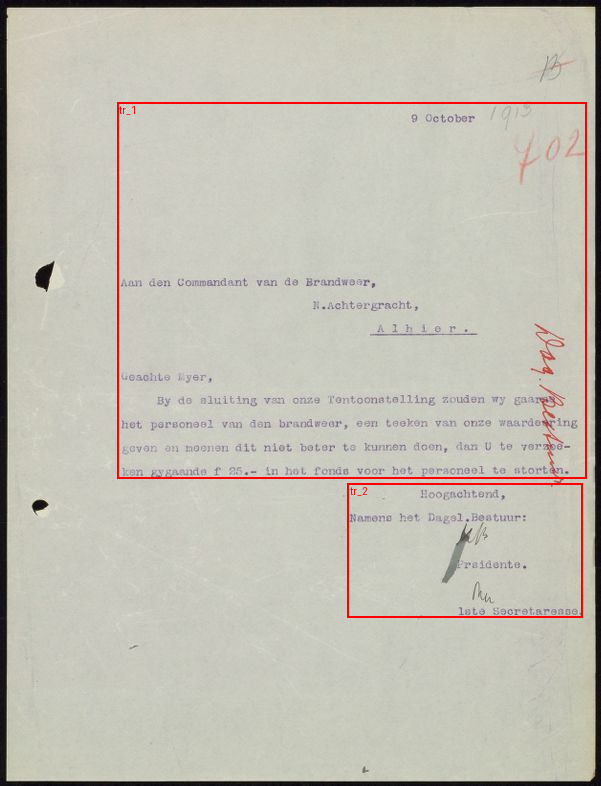

In [4]:
def load_scan_and_image(xml_stem: str):
    xml_path = PAGEXML_DIR / f"{xml_stem}.xml"
    thumb_path = thumb_by_stem[xml_stem]
    image_rgb = load_image(str(thumb_path))
    scan = pagexml_parser.parse_pagexml_file(str(xml_path))
    scan = rescale_pagexml_scan_to_image(scan, image_rgb)
    image_sel = make_selection(scan.coords.w, scan.coords.h, str(thumb_path), as_array=True)
    thumb_image = Image.open(thumb_path).convert('RGB')
    return scan, image_rgb, image_sel, thumb_image


def draw_boxes(image: Image.Image, boxes: list[Box], outline="red", width=2) -> Image.Image:
    """Return a copy of `image` with `boxes` drawn on it as rectangles, labelled if `box.label` is set."""
    annotated = image.copy()
    draw = ImageDraw.Draw(annotated)
    for box in boxes:
        draw.rectangle([box.x, box.y, box.x + box.w, box.y + box.h], outline=outline, width=width)
        if box.label:
            draw.text((box.x + 2, box.y + 2), box.label, fill=outline)
    return annotated


CANDIDATE_RANK = 0
candidate = screen_df.iloc[CANDIDATE_RANK]
scan, image_rgb, image_sel, thumb_image = load_scan_and_image(candidate['xml_stem'])
print(f"scan: {scan.id}  ink_chroma_spread={candidate['ink_chroma_spread']:.2f}  "
     f"n_ink_like_luminosity_classes={candidate['n_ink_like_luminosity_classes']}")

text_regions = scan.get_textual_regions()
thumb_boxes = [image_sel.scan_to_thumb.apply(region_to_box(region)) for region in text_regions]
draw_boxes(thumb_image, thumb_boxes)

### Zoom into the largest text lines

The clearest way to confirm "are there really multiple ink colours here" is to look directly
at the actual pixels of the largest lines, scaled up -- no colour machinery needed, just a
closer look than the full-page thumbnail allows.

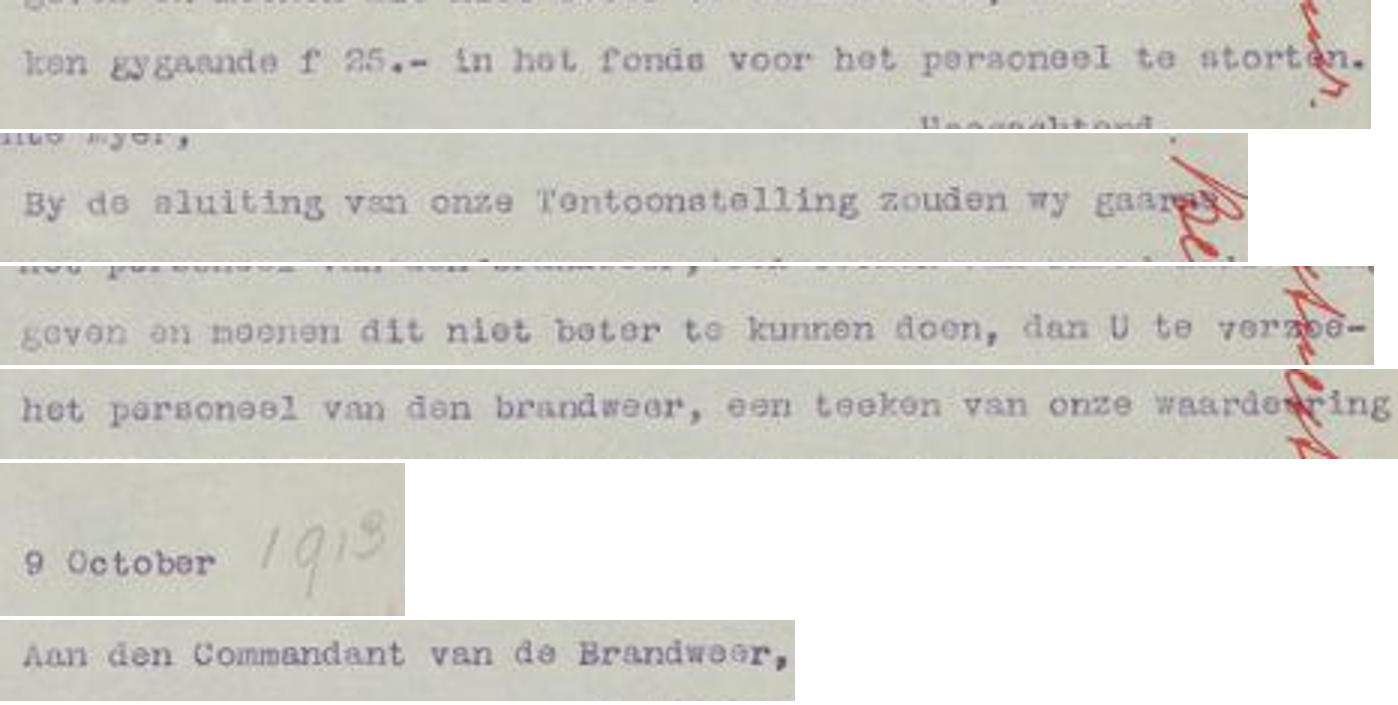

In [5]:
def crop_largest_lines(scan, image_sel, image_rgb, n: int = 6, scale: int = 3, padding: int = 2) -> Image.Image:
    """Crop `scan`'s `n` largest text lines from the thumbnail, scale each up by `scale`, and
    tile them in a single column for a close look at their actual ink colour(s)."""
    lines = sorted(scan.get_lines(), key=lambda line: -line.coords.width * line.coords.height)[:n]
    crops = []
    for line in lines:
        box = image_sel.scan_to_thumb.apply(region_to_box(line))
        padded = Box(max(0, box.x - padding), max(0, box.y - padding),
                    box.w + 2 * padding, box.h + 2 * padding)
        crop = crop_box_from_image(image_rgb, padded)
        if crop.size == 0:
            continue
        crop_img = Image.fromarray(crop)
        crops.append(crop_img.resize((crop_img.width * scale, crop_img.height * scale)))

    if not crops:
        return Image.new('RGB', (1, 1), 'white')
    width = max(c.width for c in crops)
    height = sum(c.height for c in crops) + 4 * len(crops)
    combined = Image.new('RGB', (width, height), 'white')
    y = 0
    for c in crops:
        combined.paste(c, (0, y))
        y += c.height + 4
    return combined


crop_largest_lines(scan, image_sel, image_rgb)

## Screen the same scan for missing-transcription candidates

`find_missing_text_candidates` (see its docstring for the full reasoning, including why a
two-page opening should be split into verso/recto first if the two sides differ tonally --
`NL-AsdSAA_89_3.1` is a `mixed` folder, not a book of openings, so that split isn't needed here).
A scan worth checking for multiple ink colours is often also worth checking for text the ATR
pipeline missed.

2 candidate region(s) flagged


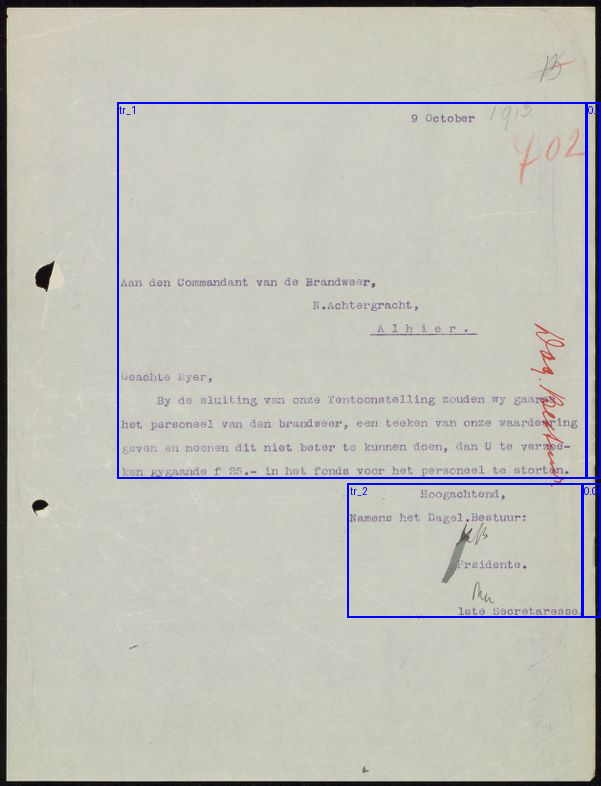

In [6]:
from pagexml.helper.spatial_helper import make_empty_regions

image_lab = rgb2lab(image_rgb.astype(np.float32) / 255.0)
for empty_region in make_empty_regions(scan):
    empty_region.set_derived_id(scan.id)
    scan.empty_regions.append(empty_region)

missing_text_candidates = find_missing_text_candidates(image_lab, scan)
print(f"{len(missing_text_candidates)} candidate region(s) flagged")

candidate_boxes = [Box(l, t, r - l, b - t, label=f"{c['ink_fraction']:.2f}")
                  for c in missing_text_candidates for (l, t, r, b) in [c['box']]]
draw_boxes(thumb_image, thumb_boxes + candidate_boxes, outline='blue')

## Manually annotate a region, write it back to the PageXML scan

As in `pagexml-image-region-linking.ipynb`'s Part 2: hard-code the box you'd otherwise draw
interactively (e.g. one of the missing-text candidates above, in thumbnail pixel coordinates),
then attach it to the scan as a new `PageXMLTextRegion`.

In [7]:
annotation_thumb_box = Box(0, 0, 0, 0, label='replace_me')  # edit to match a real candidate above

annotation_scan_box = image_sel.thumb_to_scan.apply(annotation_thumb_box)
new_region = box_to_text_region(annotation_scan_box, doc_id=f"{scan.id}-manual-1")

print(f"text regions before: {len(scan.text_regions)}")
scan.add_child(new_region)
print(f"text regions after:  {len(scan.text_regions)}")
print(f"new region: id={new_region.id}, coords.box={new_region.coords.box}")

text regions before: 2
text regions after:  3
new region: id=0844_00844.jpg-manual-1, coords.box={'x': 0, 'y': 0, 'w': 0, 'h': 0}
